<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module3_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Upload the diabetes data CSV file
from google.colab import files
uploaded = files.upload()

Saving diabetes (1).csv to diabetes (1).csv


In [ ]:
# Load the dataset
diabetes_data = pd.read_csv('diabetes (1).csv')

In [ ]:
# Display the first few rows
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
# Check dataset dimensions
print(f"Dataset shape: {diabetes_data.shape}")
print(f"Number of samples: {diabetes_data.shape[0]}")
print(f"Number of features: {diabetes_data.shape[1]}")

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 9


In [ ]:
# Dataset information
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
# Check for missing values
print("Missing values per column:")
print(diabetes_data.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Descriptive statistics
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Check the target variable distribution
print("Outcome distribution:")
print(diabetes_data['Outcome'].value_counts())
print(f"\nPercentage of diabetic cases: {diabetes_data['Outcome'].mean()*100:.2f}%")

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of diabetic cases: 34.90%


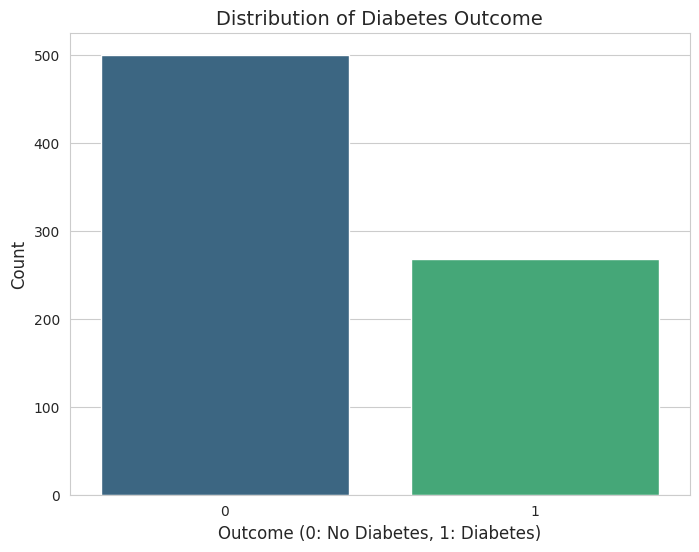

In [14]:
# Visualize the target variable distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes_data, palette='viridis')
plt.title('Distribution of Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

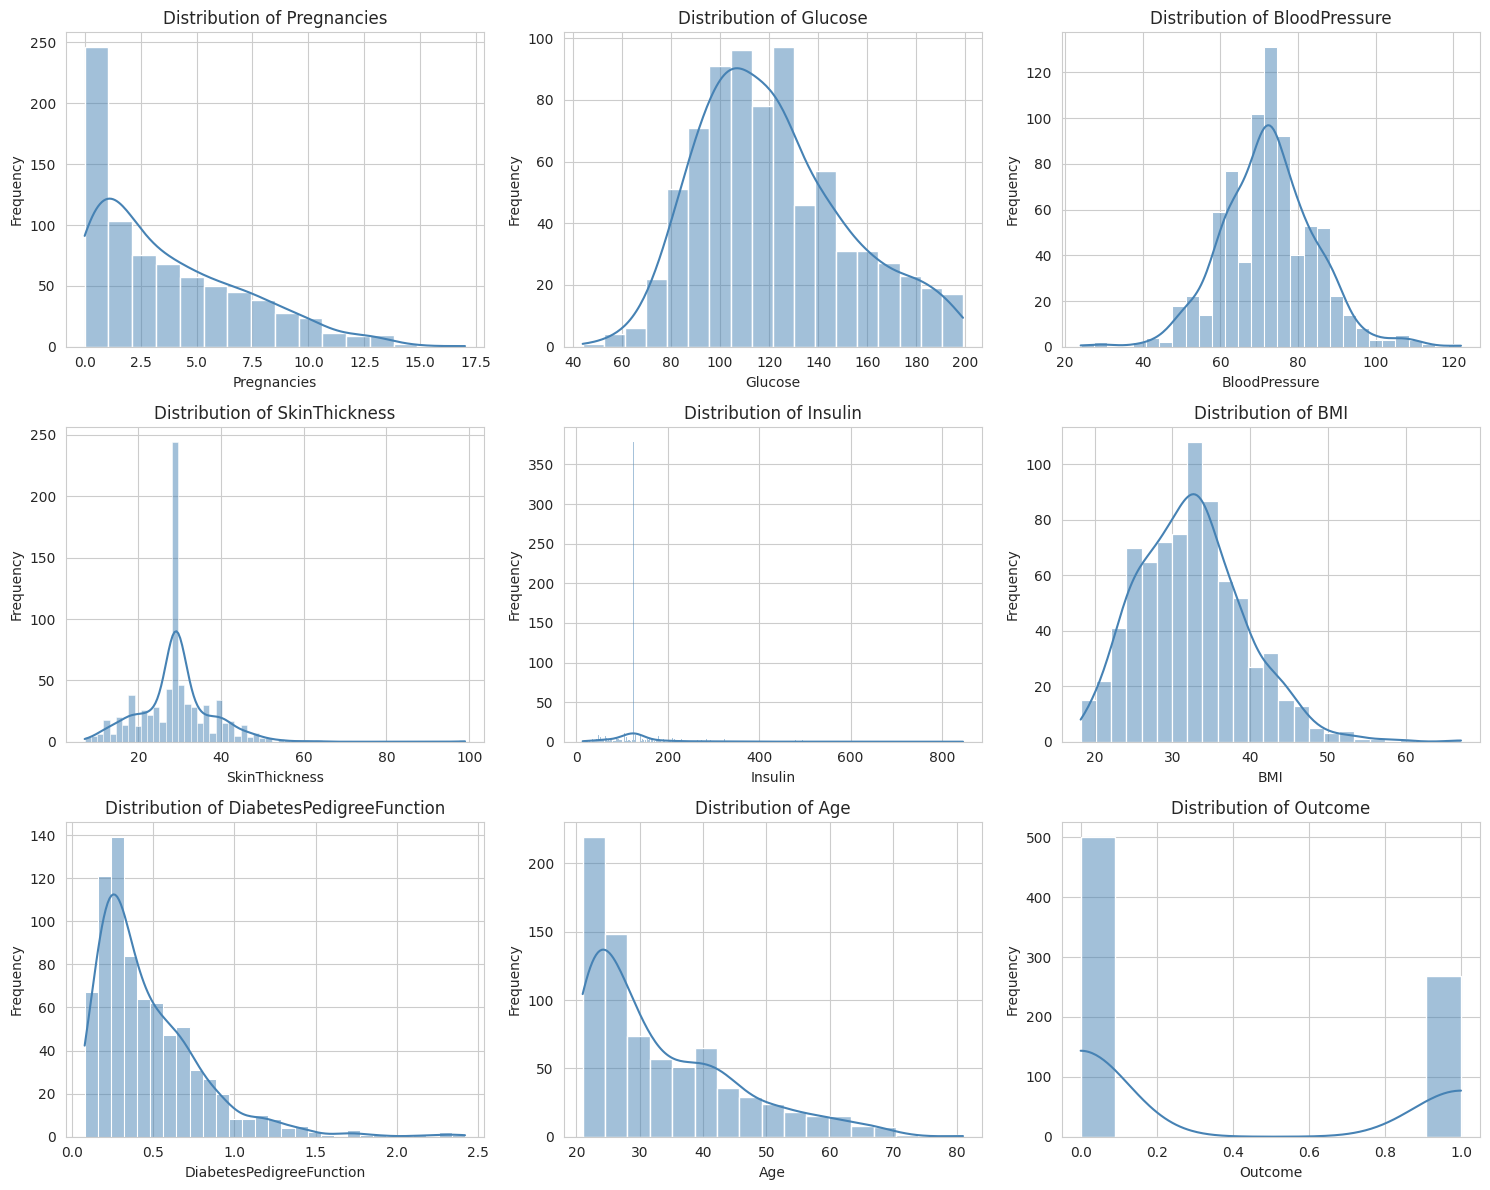

In [ ]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(diabetes_data.columns):
    sns.histplot(diabetes_data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

## TASK-1: Correlation Analysis

Compute the correlation matrix and visualize it using a heatmap to understand the relationships between different features.

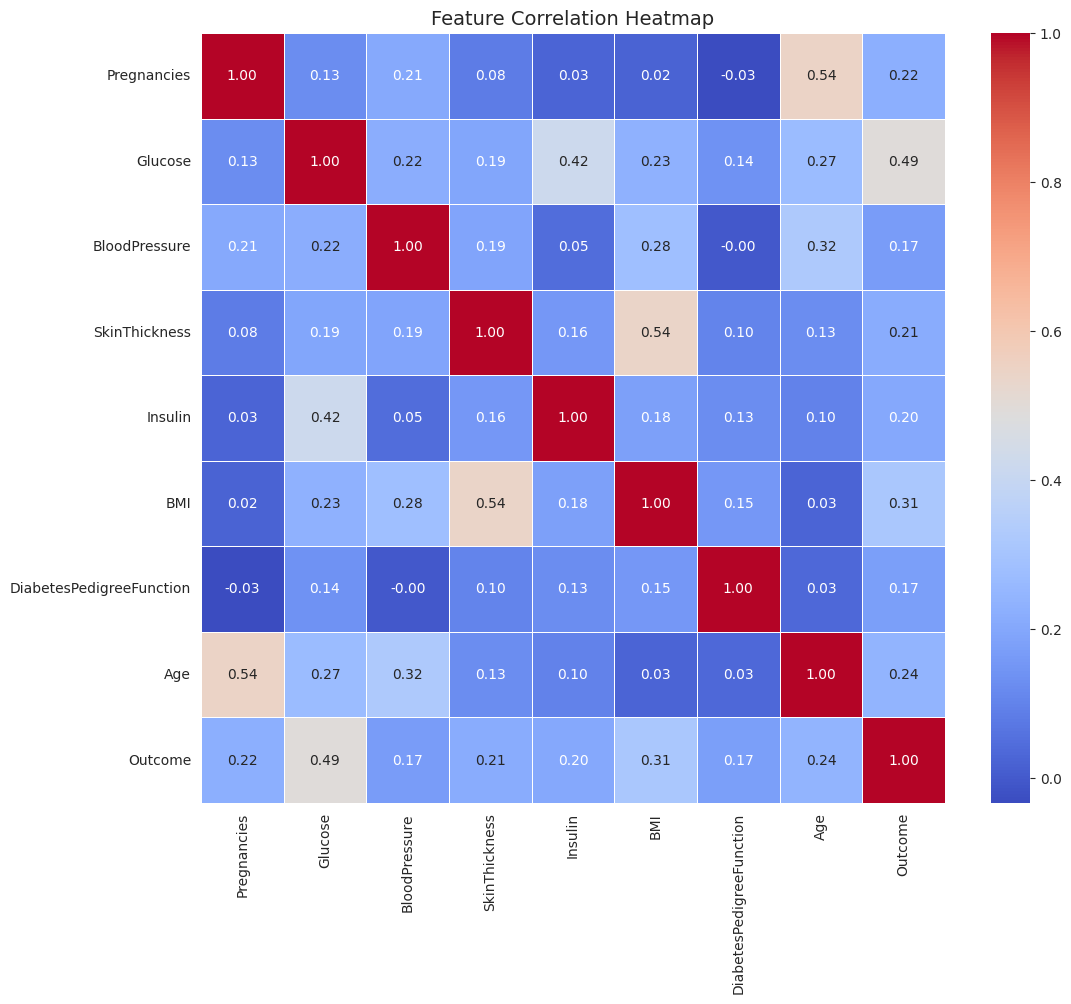

In [ ]:
# Calculate correlation matrix
correlation_matrix = diabetes_data.corr()

# Visualize with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

From the analysis, Glucose has the strongest positive correlation with the Outcome variable (r = 0.493). This indicates that individuals with higher glucose levels are more likely to be diagnosed with diabetes. Therefore, glucose is the most significant predictor in this dataset.

BMI (Body Mass Index) shows the second-highest correlation with Outcome (r = 0.312), suggesting that increased body weight is associated with a higher risk of diabetes. Age (r = 0.238) and Pregnancies (r = 0.222) also exhibit positive correlations, indicating that older individuals and women with a greater number of pregnancies tend to have a higher likelihood of developing diabetes.

Other features such as Skin Thickness (r = 0.215), Insulin (r = 0.204), Diabetes Pedigree Function (r = 0.174), and Blood Pressure (r = 0.166) show weaker positive correlations with the Outcome variable. Although these factors contribute to diabetes prediction, their individual influence is less significant compared to glucose and BMI.

The heatmap also shows that there are no extremely high correlations among the predictor variables themselves. This suggests that multicollinearity is not a major issue in the dataset, and each feature provides useful information for diabetes prediction.

## TASK-2: Comparative Box Plots

Create box plots to compare the distribution of each feature for diabetic vs non-diabetic patients.

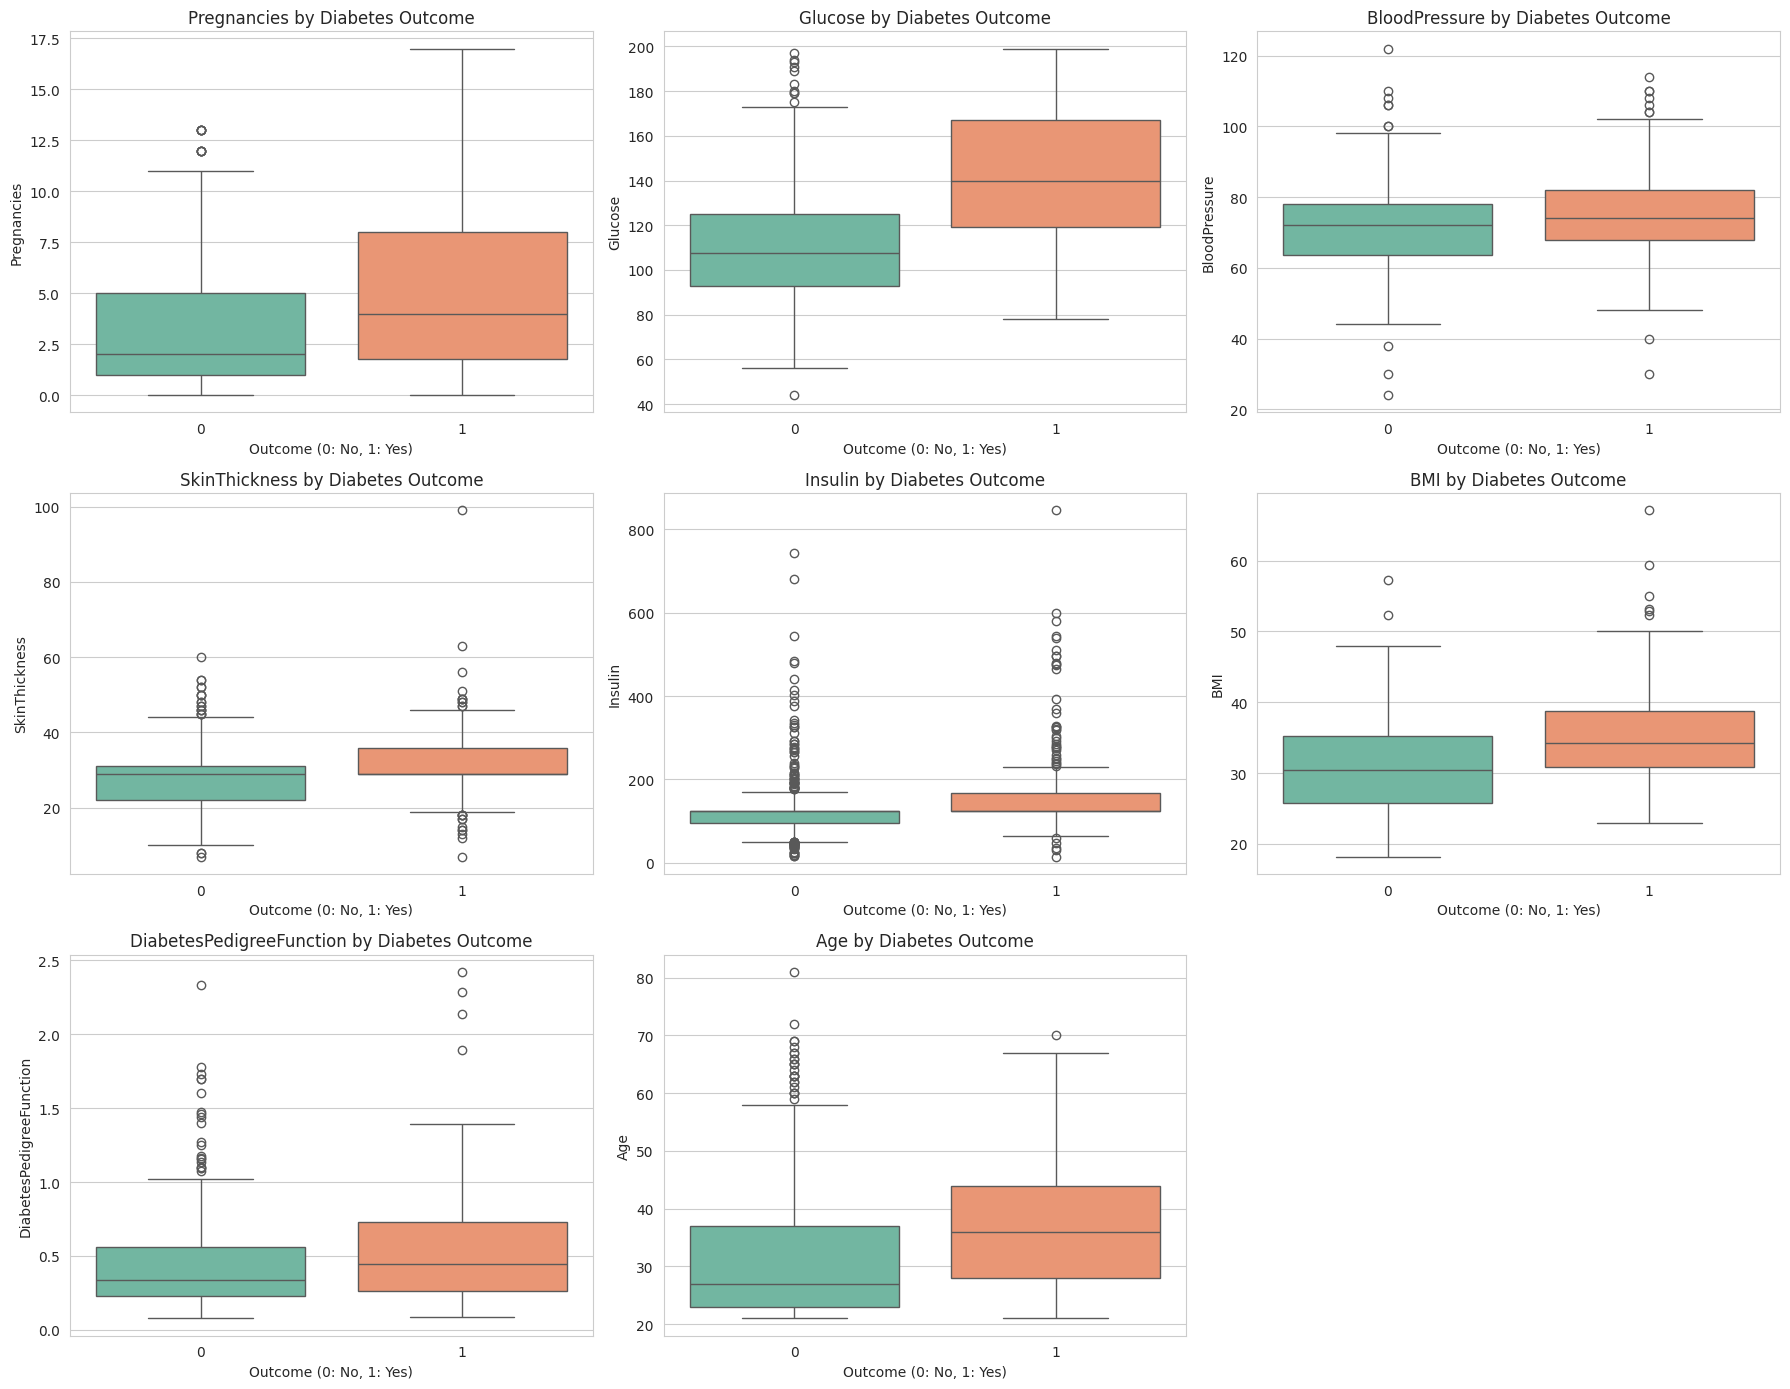

In [20]:
# Box plots for all features grouped by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

feature_cols = diabetes_data.columns[:-1]  # All columns except Outcome

for i, col in enumerate(feature_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes_data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=12)
    axes[i].set_xlabel('Outcome (0: No, 1: Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# Hide the last subplot if not needed
axes[-1].axis('off')

plt.tight_layout()
plt.show()

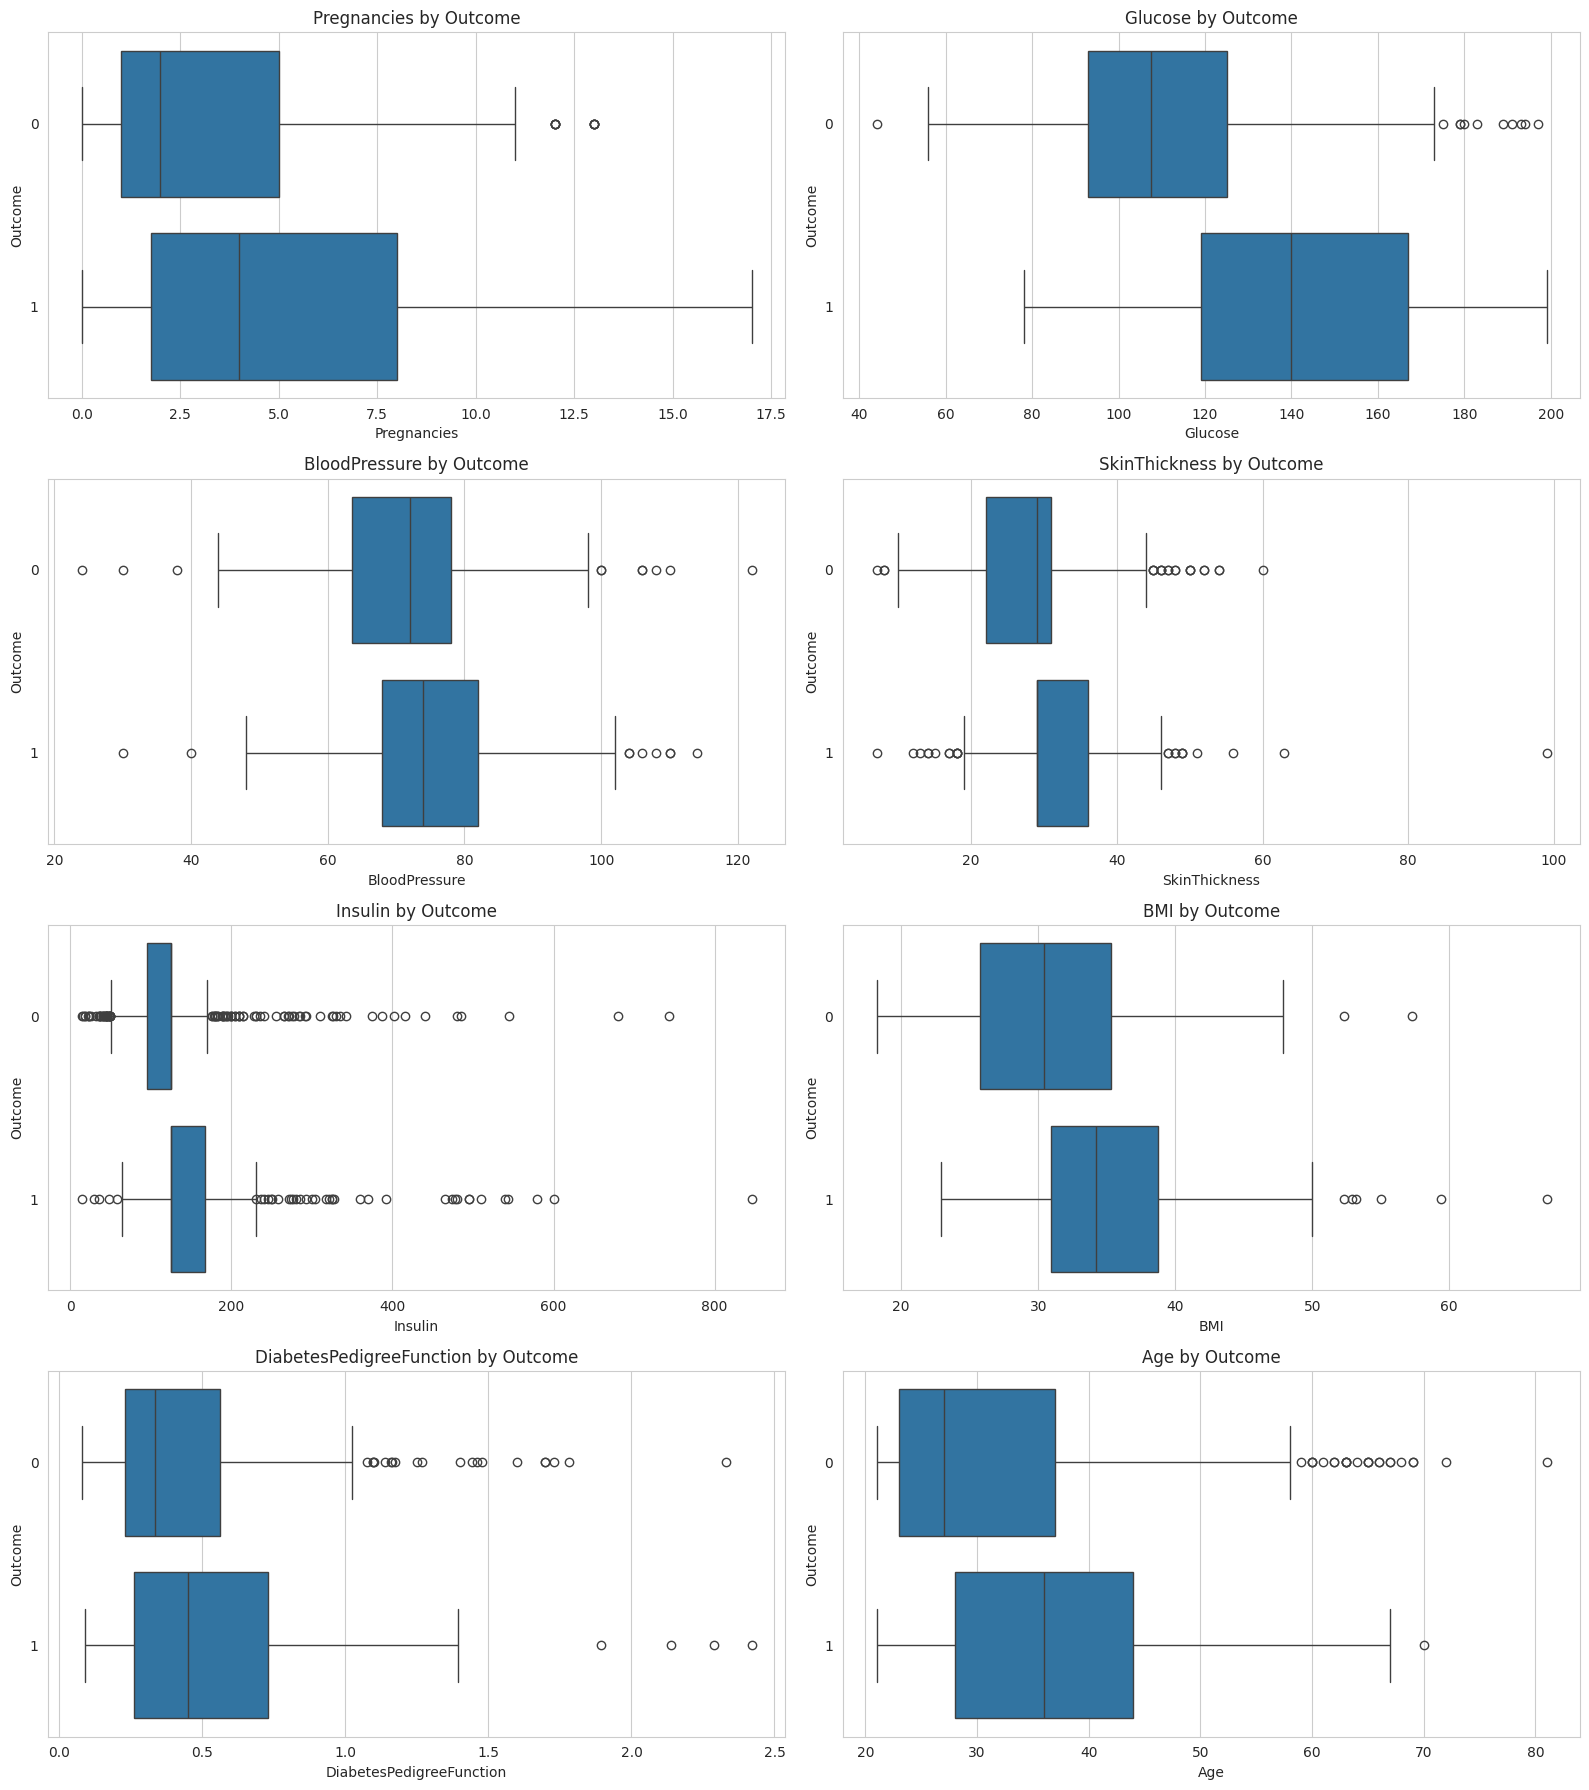

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(diabetes_data.columns[:-1]):
    sns.boxplot(data=diabetes_data,
                y='Outcome',
                x=feature,
                orient='h',
                ax=axes[i])

    axes[i].set_title(f'{feature} by Outcome')

plt.tight_layout()
plt.show()

## TASK-3: Pairplot Analysis

Create a pairplot to visualize the pairwise relationships between features, colored by the Outcome variable.

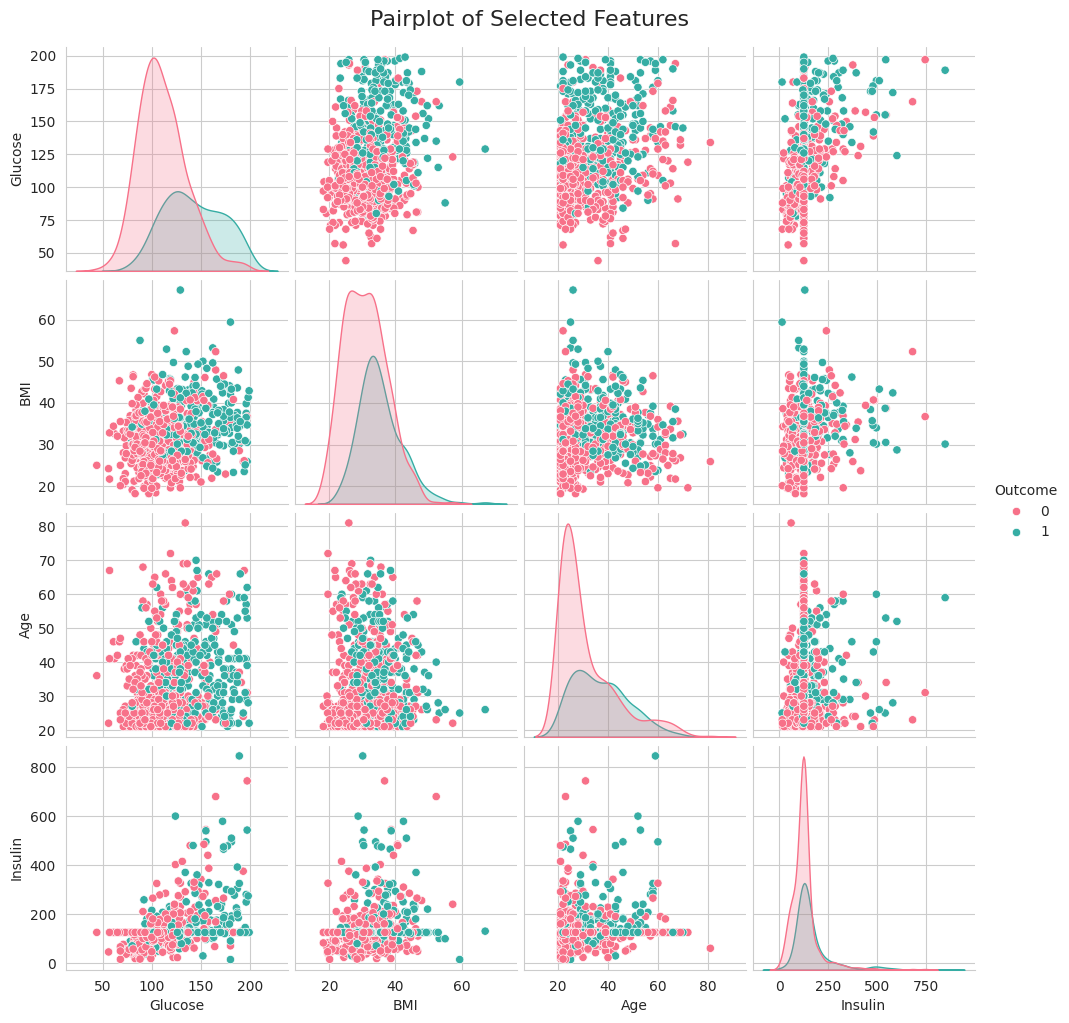

In [23]:
# Select a subset of features for clearer visualization
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(diabetes_data[selected_features], hue='Outcome', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=16)
plt.show()

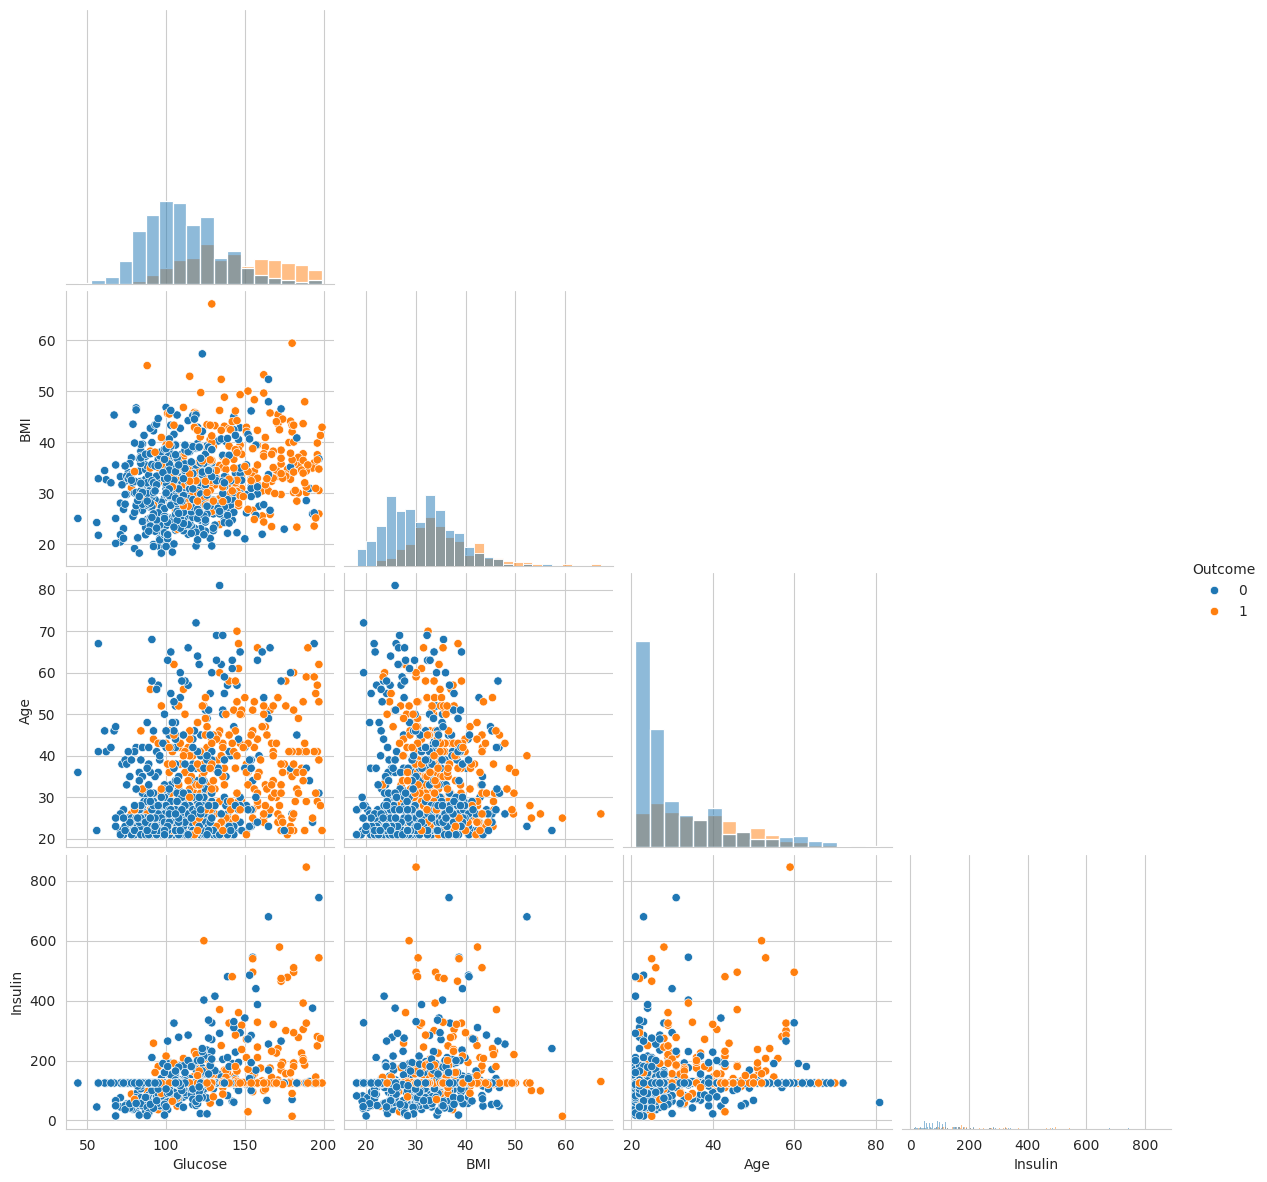

In [24]:
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

sns.pairplot(
    diabetes_data[selected_features],
    hue='Outcome',
    corner=True,
    diag_kind='hist',
    height=3
)

plt.show()

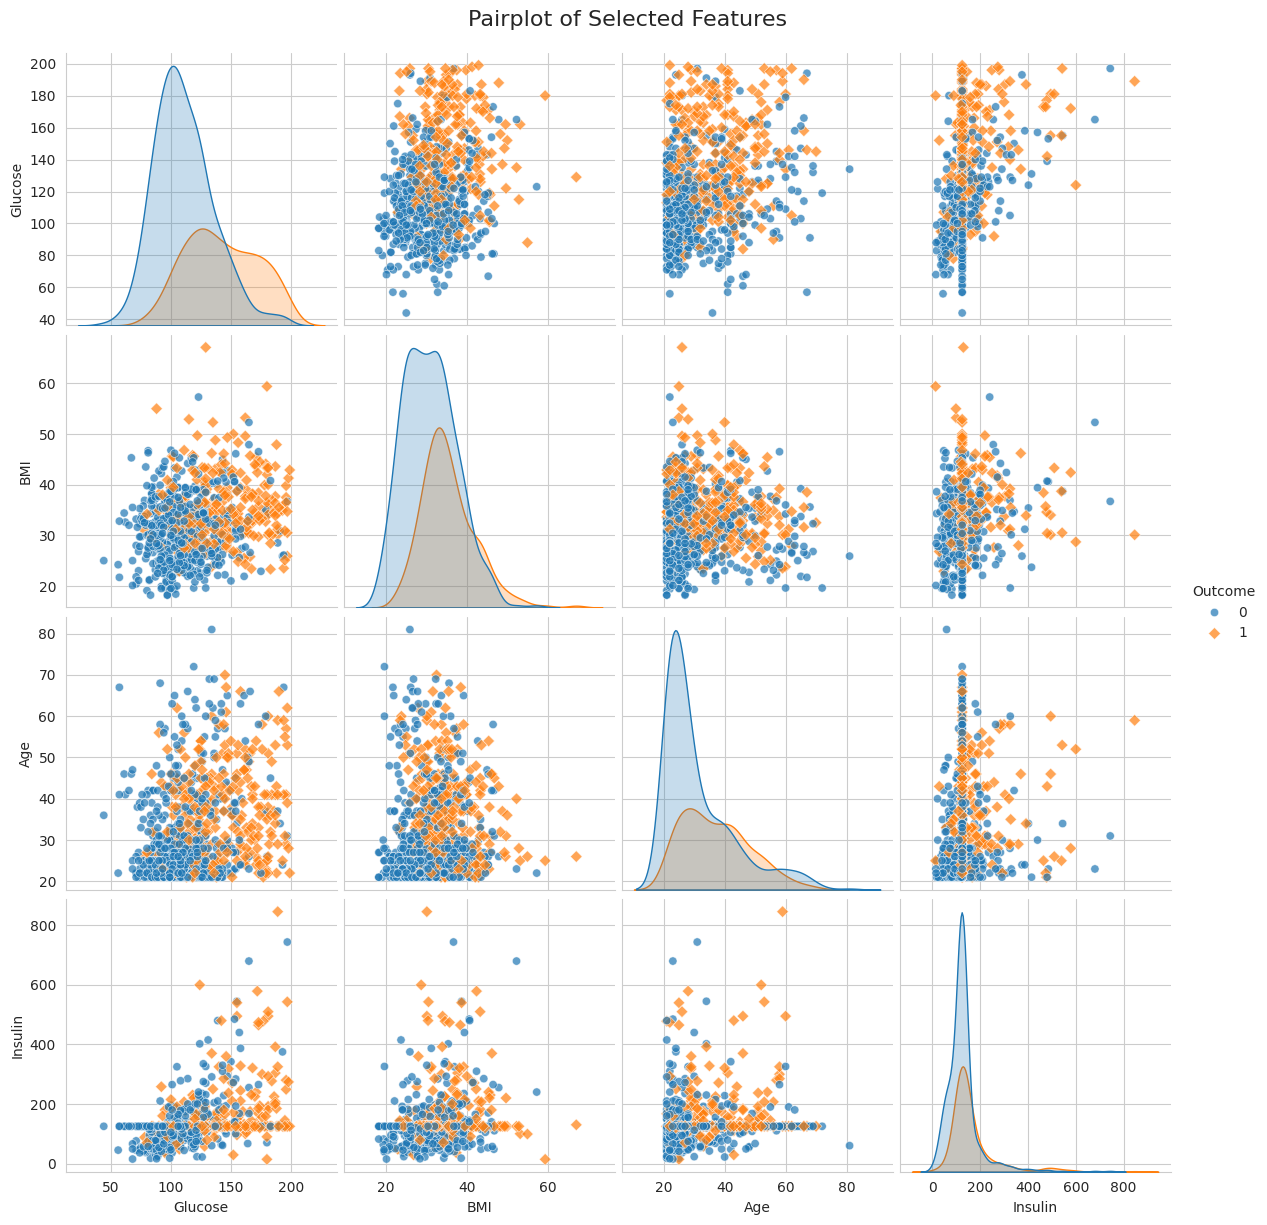

In [27]:
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

sns.pairplot(
    diabetes_data[selected_features],
    hue='Outcome',
    diag_kind='kde',
    markers=['o', 'D'],
    height=3,
    plot_kws={'alpha':0.7}
)

plt.suptitle('Pairplot of Selected Features',
             y=1.02, fontsize=16)
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## TASK-4: Train-Test Split

Split the dataset into training (70%) and testing (30%) sets.

In [29]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 537
Testing set size: 231


The dataset was divided into training and testing sets using the train_test_split() function from Scikit-Learn. The training set consists of 70% of the data and is used to train the machine learning model, while the testing set consists of the remaining 30% and is used to evaluate the model's performance on unseen data.

This separation helps prevent overfitting and provides an unbiased estimate of how well the model will perform on new data. The feature variables were stored in X, while the target variable (Outcome) was stored in y. After splitting, the training data is used to build the K-Nearest Neighbors (KNN) classifier, and the testing data is used to assess its accuracy and classification performance.

In [30]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (537, 8)
Testing Features Shape: (231, 8)
Training Labels Shape: (537,)
Testing Labels Shape: (231,)


## TASK-5: Build and Evaluate KNN Model

Train a KNN classifier with k=1 and evaluate its performance.

In [31]:
# Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Confusion Matrix:
[[114  36]
 [ 40  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       150
           1       0.53      0.51      0.52        81

    accuracy                           0.67       231
   macro avg       0.64      0.63      0.63       231
weighted avg       0.67      0.67      0.67       231


Accuracy Score: 67.10%


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

Accuracy: 71.86147186147186


## TASK-6: Finding the Optimal K Value

Test different values of K (from 1 to 40) and plot the error rate to find the optimal K value.

In [36]:
# Store the original unscaled data for later comparison
unchanged_data = X.copy()

# Function to evaluate KNN performance across different K values
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.3, random_state=101)

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    # Plot error rate
    plt.figure(figsize=(12, 8))
    plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=8)
    plt.title('Error Rate vs. K Value', fontsize=14)
    plt.xlabel('K', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find best K values
    max_train_score = max(train_scores)
    train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
    print(f'Max train score: {max_train_score*100:.2f}% at K = {[x+1 for x in train_scores_ind]}')

    max_test_score = max(test_scores)
    test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
    print(f'Max test score: {max_test_score*100:.2f}% at K = {[x+1 for x in test_scores_ind]}')

    return test_scores

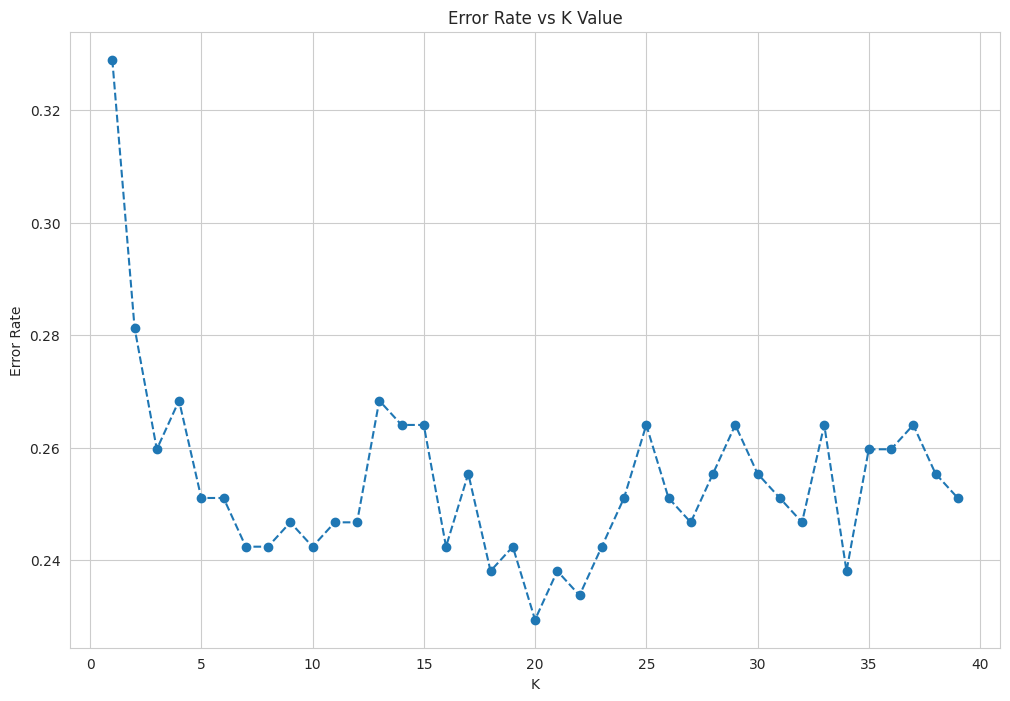

[0.670995670995671,
 0.7186147186147186,
 0.7402597402597403,
 0.7316017316017316,
 0.7489177489177489,
 0.7489177489177489,
 0.7575757575757576,
 0.7575757575757576,
 0.7532467532467533,
 0.7575757575757576,
 0.7532467532467533,
 0.7532467532467533,
 0.7316017316017316,
 0.7359307359307359,
 0.7359307359307359,
 0.7575757575757576,
 0.7445887445887446,
 0.7619047619047619,
 0.7575757575757576,
 0.7705627705627706,
 0.7619047619047619,
 0.7662337662337663,
 0.7575757575757576,
 0.7489177489177489,
 0.7359307359307359,
 0.7489177489177489,
 0.7532467532467533,
 0.7445887445887446,
 0.7359307359307359,
 0.7445887445887446,
 0.7489177489177489,
 0.7532467532467533,
 0.7359307359307359,
 0.7619047619047619,
 0.7402597402597403,
 0.7402597402597403,
 0.7359307359307359,
 0.7445887445887446,
 0.7489177489177489]

In [37]:
# Function definition
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(
        xdata, ydata,
        test_size=0.3,
        random_state=101
    )

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train, y_train)

        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    plt.figure(figsize=(12,8))
    plt.plot(range(1,40), error_rate,
             marker='o',
             linestyle='dashed')

    plt.title('Error Rate vs K Value')
    plt.xlabel('K')
    plt.ylabel('Error Rate')
    plt.show()

    return test_scores

# Function call
plot_KNN_error_rate(X, y)

Performance on Unscaled Data:


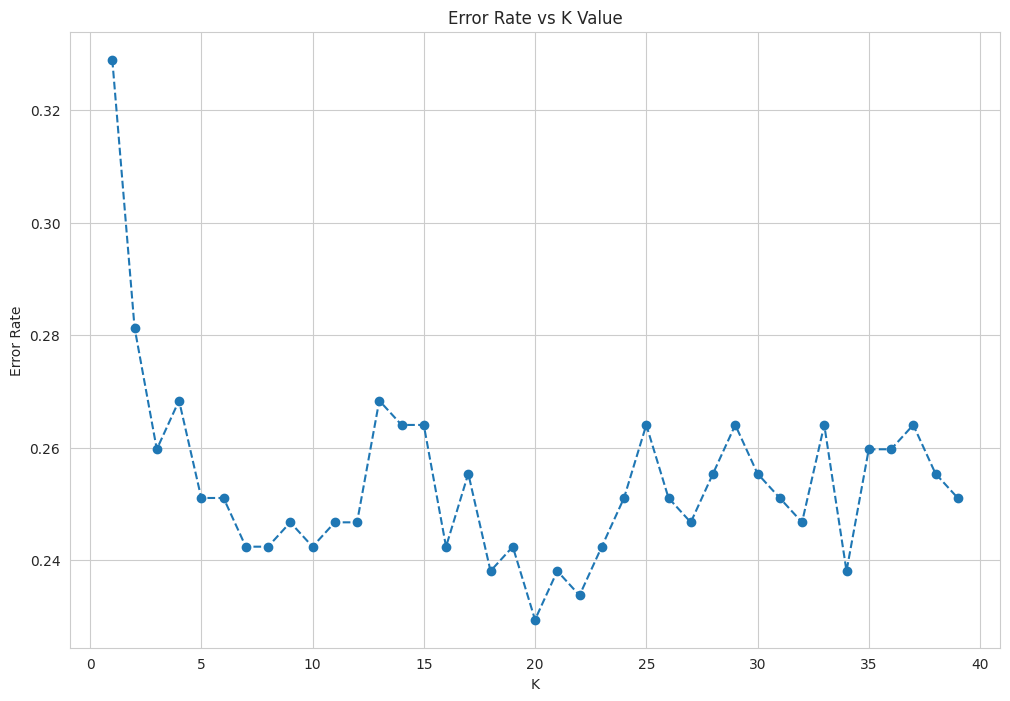

In [38]:
# Evaluate on unscaled data
print("Performance on Unscaled Data:")
unchanged_test_scores = plot_KNN_error_rate(unchanged_data, diabetes_data['Outcome'])

In [39]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data features
scaler.fit(diabetes_data.drop('Outcome', axis=1))

# Transform the features
scaled_data = scaler.transform(diabetes_data.drop('Outcome', axis=1))

In [40]:
# Create a dataframe with scaled features
df_feat = pd.DataFrame(scaled_data, columns=diabetes_data.columns[:-1])
df_feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [41]:
# Verify standardization: mean should be ~0, std should be ~1
print("Mean of scaled features:")
print(df_feat.mean())
print("\nStandard deviation of scaled features:")
print(df_feat.std())

Mean of scaled features:
Pregnancies                -6.476301e-17
Glucose                    -3.561966e-16
BloodPressure              -4.325244e-16
SkinThickness              -1.526557e-16
Insulin                     1.503427e-17
BMI                         2.613650e-16
DiabetesPedigreeFunction    2.174187e-16
Age                         1.931325e-16
dtype: float64

Standard deviation of scaled features:
Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
dtype: float64


Performance on Standardized Data:


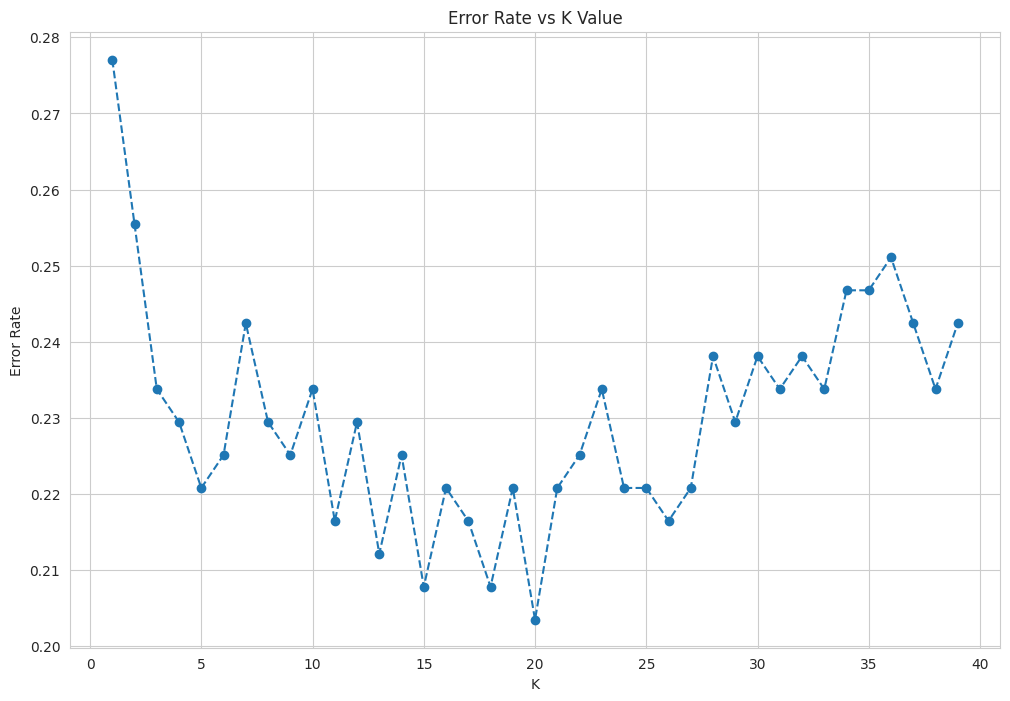

In [42]:
# Evaluate on scaled data
print("Performance on Standardized Data:")
scaled_test_scores = plot_KNN_error_rate(scaled_data, diabetes_data['Outcome'])

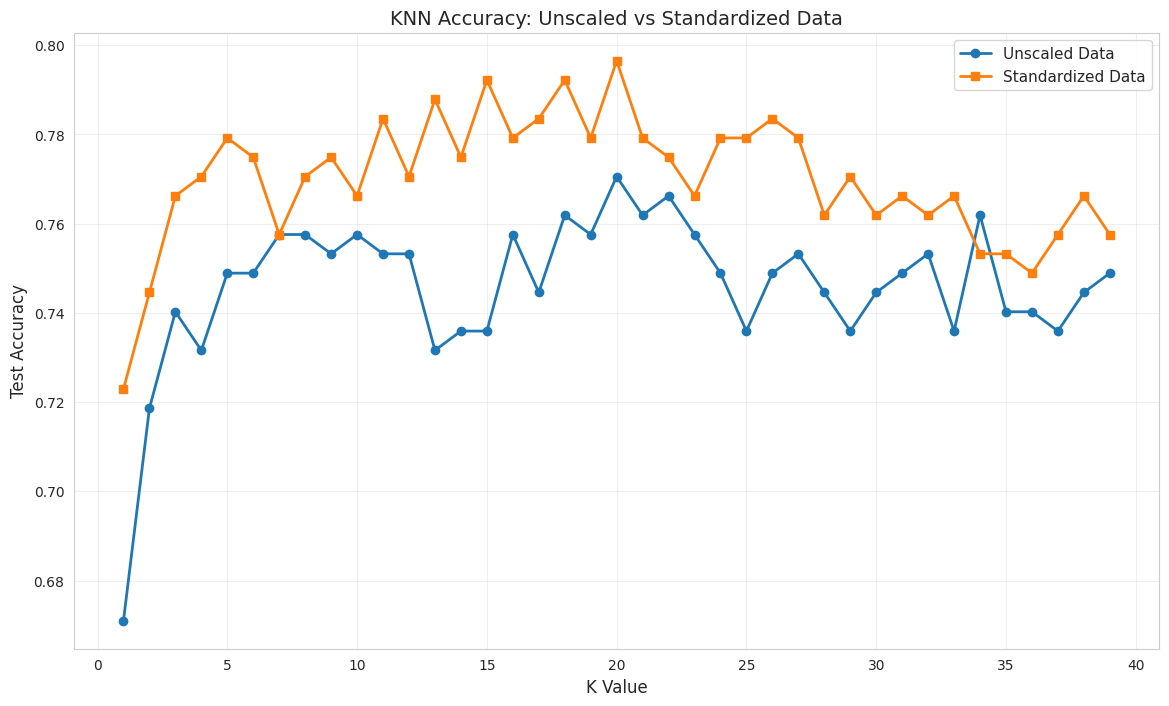

In [43]:
# Compare performance
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='s', label='Standardized Data', linewidth=2)
plt.title('KNN Accuracy: Unscaled vs Standardized Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Challenge 1: MinMax Scaling Comparison

**Objective:** Implement MinMax scaling and compare its performance with StandardScaler.

**Tasks:**
1. Import `MinMaxScaler` from sklearn.preprocessing
2. Apply MinMax scaling to the dataset (scales features to range [0, 1])
3. Use the `plot_KNN_error_rate()` function on the MinMax-scaled data
4. Create a comparison plot showing all three approaches: unscaled, standardized, and MinMax-scaled
5. Analyze which scaling method performs best and why

**Hint:** MinMaxScaler formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

Performance on MinMax Scaled Data:


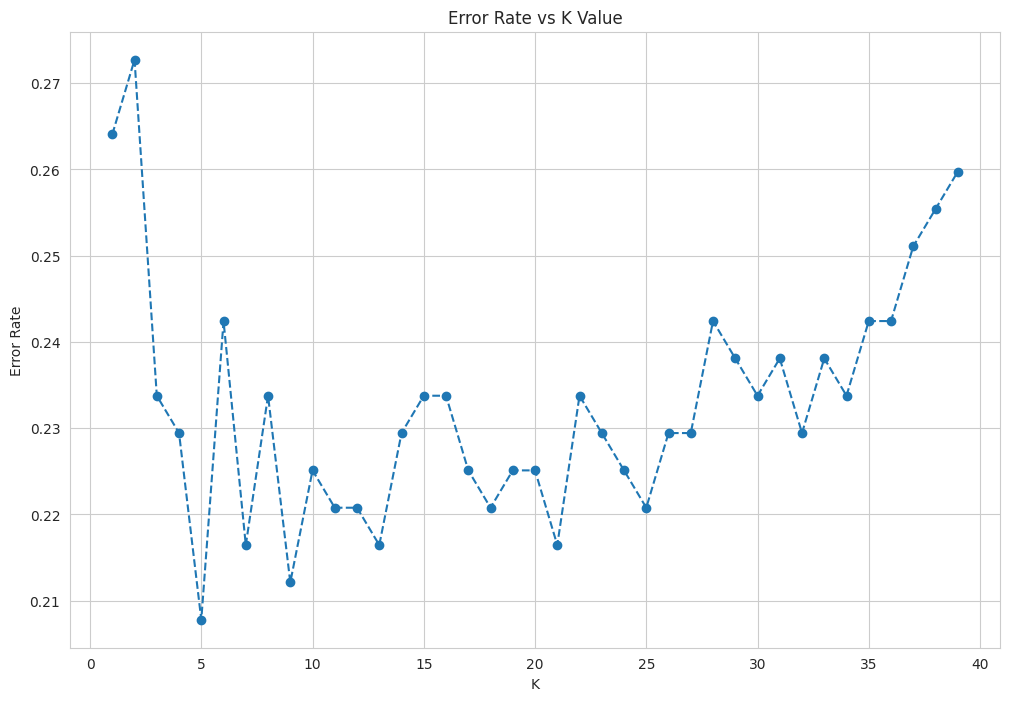

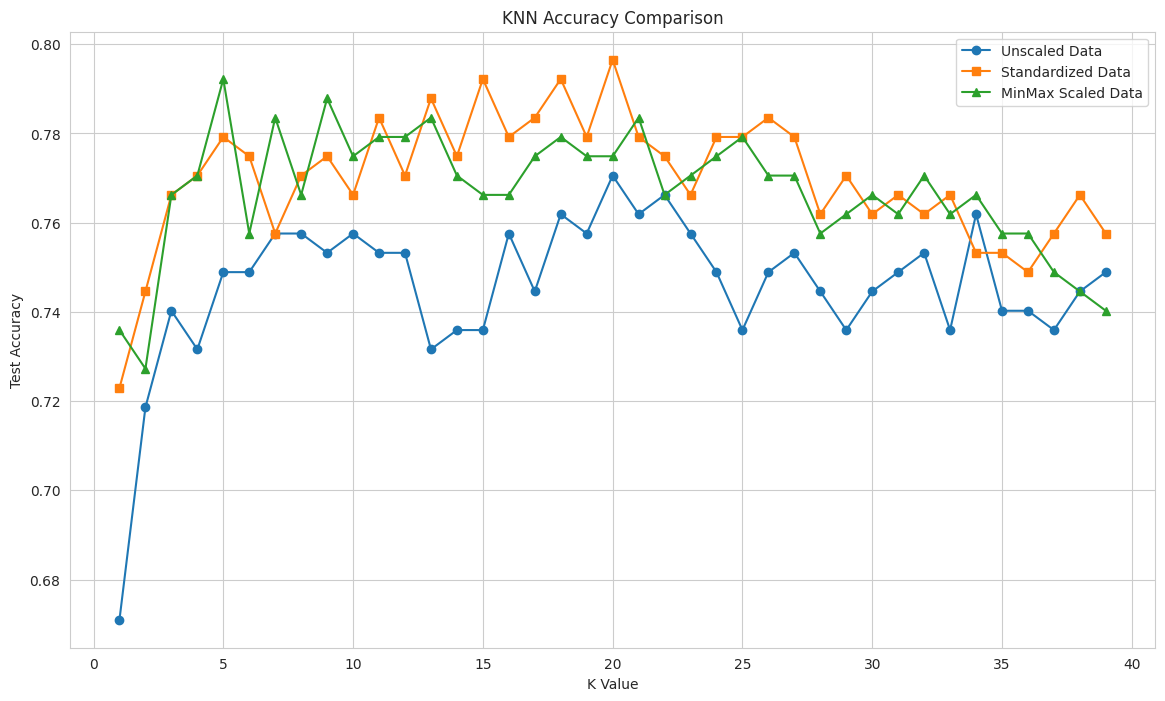

In [44]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMax Scaler
minmax_scaler = MinMaxScaler()

# Fit and transform the features
minmax_scaled_data = minmax_scaler.fit_transform(
    diabetes_data.drop('Outcome', axis=1)
)

# Evaluate on MinMax-scaled data
print("Performance on MinMax Scaled Data:")
minmax_test_scores = plot_KNN_error_rate(
    minmax_scaled_data,
    diabetes_data['Outcome']
)

# Compare all three approaches
plt.figure(figsize=(14, 8))

plt.plot(range(1, 40),
         unchanged_test_scores,
         marker='o',
         label='Unscaled Data')

plt.plot(range(1, 40),
         scaled_test_scores,
         marker='s',
         label='Standardized Data')

plt.plot(range(1, 40),
         minmax_test_scores,
         marker='^',
         label='MinMax Scaled Data')

plt.title('KNN Accuracy Comparison')
plt.xlabel('K Value')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## Challenge 2: K-Fold Cross-Validation Analysis

**Objective:** Implement K-Fold cross-validation to get more robust performance estimates.

**Tasks:**
1. Import `cross_val_score` from sklearn.model_selection
2. Implement 5-fold cross-validation for KNN with K values from 1 to 40
3. Compare cross-validation scores for:
   - Unscaled data
   - Standardized data
   - MinMax-scaled data (from Challenge 1)
4. Plot the mean cross-validation accuracy with standard deviation error bars
5. Determine the optimal K value for each scaling approach

**Bonus:** Calculate and display the standard deviation of cross-validation scores to understand model stability.

In [45]:
from sklearn.model_selection import cross_val_score

In [46]:
def kfold_knn_analysis(X_data, y_data, dataset_name):

    mean_scores = []
    std_scores = []

    for k in range(1, 41):
        knn = KNeighborsClassifier(n_neighbors=k)

        cv_scores = cross_val_score(
            knn,
            X_data,
            y_data,
            cv=5,
            scoring='accuracy'
        )

        mean_scores.append(cv_scores.mean())
        std_scores.append(cv_scores.std())

    best_k = mean_scores.index(max(mean_scores)) + 1

    print(f"\n{dataset_name}")
    print(f"Best K = {best_k}")
    print(f"Best Cross-Validation Accuracy = {max(mean_scores)*100:.2f}%")

    return mean_scores, std_scores, best_k

In [47]:
# Unscaled Data
unscaled_mean, unscaled_std, unscaled_best_k = kfold_knn_analysis(
    unchanged_data,
    diabetes_data['Outcome'],
    "Unscaled Data"
)

# Standardized Data
standard_mean, standard_std, standard_best_k = kfold_knn_analysis(
    scaled_data,
    diabetes_data['Outcome'],
    "Standardized Data"
)

# MinMax Scaled Data
minmax_mean, minmax_std, minmax_best_k = kfold_knn_analysis(
    minmax_scaled_data,
    diabetes_data['Outcome'],
    "MinMax Scaled Data"
)


Unscaled Data
Best K = 31
Best Cross-Validation Accuracy = 75.26%

Standardized Data
Best K = 25
Best Cross-Validation Accuracy = 77.22%

MinMax Scaled Data
Best K = 21
Best Cross-Validation Accuracy = 77.35%


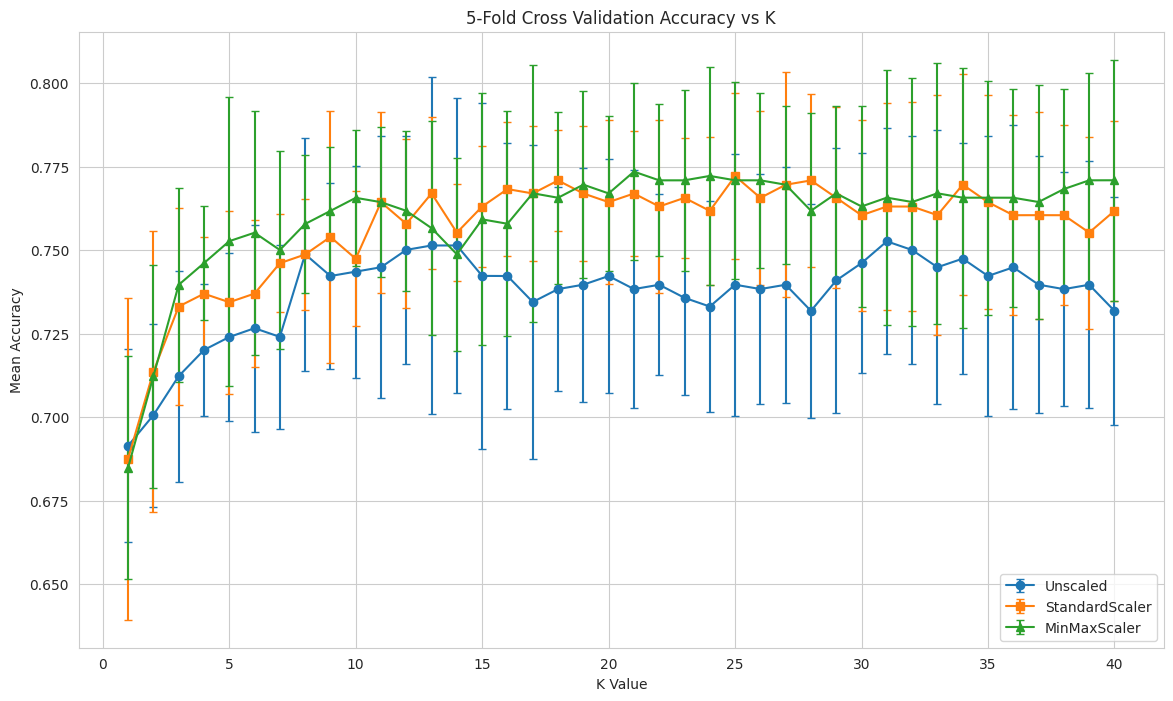

In [48]:
plt.figure(figsize=(14,8))

plt.errorbar(
    range(1,41),
    unscaled_mean,
    yerr=unscaled_std,
    label='Unscaled',
    marker='o',
    capsize=3
)

plt.errorbar(
    range(1,41),
    standard_mean,
    yerr=standard_std,
    label='StandardScaler',
    marker='s',
    capsize=3
)

plt.errorbar(
    range(1,41),
    minmax_mean,
    yerr=minmax_std,
    label='MinMaxScaler',
    marker='^',
    capsize=3
)

plt.title('5-Fold Cross Validation Accuracy vs K')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [49]:
print("\nOptimal K Values")

print("Unscaled Data:")
print("Best K =", unscaled_best_k)

print("\nStandardized Data:")
print("Best K =", standard_best_k)

print("\nMinMax Scaled Data:")
print("Best K =", minmax_best_k)


Optimal K Values
Unscaled Data:
Best K = 31

Standardized Data:
Best K = 25

MinMax Scaled Data:
Best K = 21


## Challenge 3: Feature Selection and Performance Analysis

**Objective:** Investigate how feature selection impacts KNN performance.

**Tasks:**
1. Based on the correlation analysis from TASK-1, identify the top 4 features most correlated with 'Outcome'
2. Create a reduced dataset with only these 4 features
3. Apply standardization to this reduced feature set
4. Train KNN models (K from 1 to 40) on both:
   - Full feature set (standardized)
   - Reduced feature set (standardized)
5. Create a comparison plot showing:
   - Accuracy vs K for full features
   - Accuracy vs K for reduced features
6. Analyze:
   - Does reducing features improve or hurt performance?
   - What is the optimal K for each feature set?
   - What insights can you draw about feature importance?

**Bonus:** Try different numbers of features (3, 5, 6) and see how it affects performance.

In [50]:
top_features = ['Glucose', 'BMI', 'Age', 'Pregnancies']

X_reduced = diabetes_data[top_features]
y = diabetes_data['Outcome']

In [51]:
from sklearn.preprocessing import StandardScaler

scaler_reduced = StandardScaler()

X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

In [52]:
full_scores = []
reduced_scores = []

for k in range(1, 41):

    # Full Feature Set
    knn_full = KNeighborsClassifier(n_neighbors=k)

    full_cv = cross_val_score(
        knn_full,
        scaled_data,
        y,
        cv=5,
        scoring='accuracy'
    )

    full_scores.append(full_cv.mean())

    # Reduced Feature Set
    knn_reduced = KNeighborsClassifier(n_neighbors=k)

    reduced_cv = cross_val_score(
        knn_reduced,
        X_reduced_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    reduced_scores.append(reduced_cv.mean())

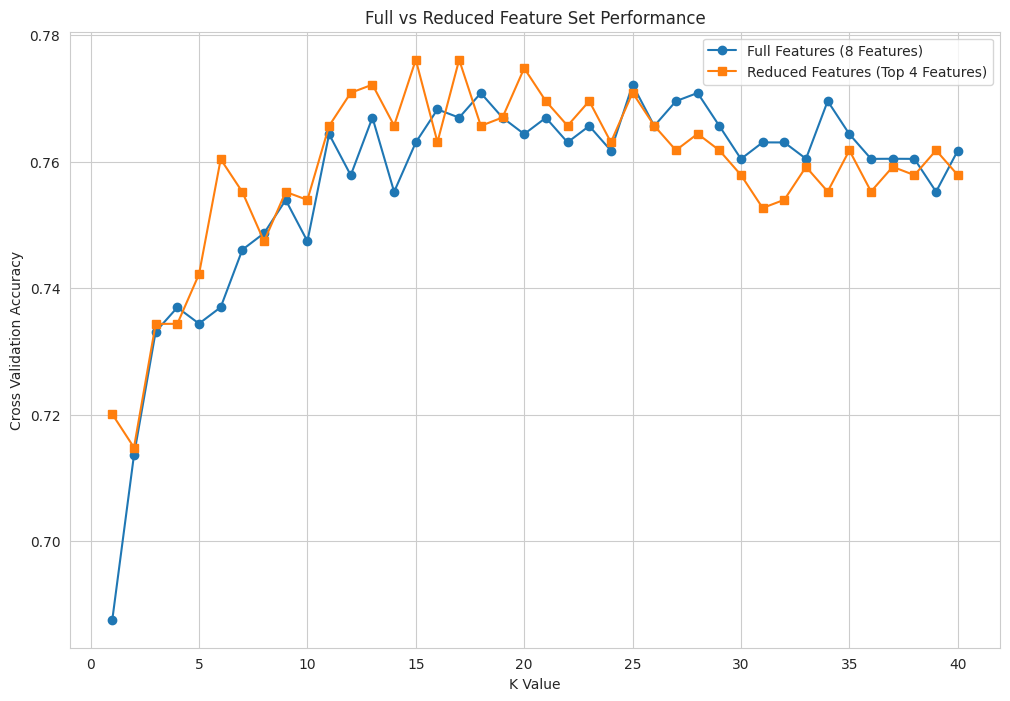

In [53]:
plt.figure(figsize=(12,8))

plt.plot(
    range(1,41),
    full_scores,
    marker='o',
    label='Full Features (8 Features)'
)

plt.plot(
    range(1,41),
    reduced_scores,
    marker='s',
    label='Reduced Features (Top 4 Features)'
)

plt.xlabel('K Value')
plt.ylabel('Cross Validation Accuracy')
plt.title('Full vs Reduced Feature Set Performance')
plt.legend()
plt.grid(True)

plt.show()

In [54]:
best_full_k = full_scores.index(max(full_scores)) + 1
best_reduced_k = reduced_scores.index(max(reduced_scores)) + 1

print("Full Feature Set")
print("Best K:", best_full_k)
print("Best Accuracy:", max(full_scores)*100)

print("\nReduced Feature Set")
print("Best K:", best_reduced_k)
print("Best Accuracy:", max(reduced_scores)*100)

Full Feature Set
Best K: 25
Best Accuracy: 77.21840251252014

Reduced Feature Set
Best K: 17
Best Accuracy: 77.6139546727782
